In [ ]:
!pip install -q sentence-transformers faiss-cpu groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 6.1 MB/s eta 0:00:00


In [ ]:
!wget -q https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip
!unzip -q scifact.zip

In [ ]:
!find scifact -maxdepth 2 -type f

scifact/corpus.jsonl
scifact/qrels/test.tsv
scifact/qrels/train.tsv
scifact/queries.jsonl


In [ ]:
import json
import time
import numpy as np
import pandas as pd
import faiss
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from groq import Groq
from google.colab import userdata

In [ ]:
corpus = {}
with open("scifact/corpus.jsonl", "r") as f:
    for line in f:
        doc = json.loads(line)
        corpus[str(doc["_id"])] = {
            "title": doc["title"],
            "text": doc["text"]
        }
print("Documents:", len(corpus))

Documents: 5183


In [ ]:
queries = {}
with open("scifact/queries.jsonl", "r") as f:
    for line in f:
        query = json.loads(line)
        queries[str(query["_id"])] = query["text"]
print("Queries:", len(queries))

Queries: 1109


In [ ]:
qrels_train = pd.read_csv(
    "scifact/qrels/train.tsv",
    sep="\t"
)
qrels_test = pd.read_csv(
    "scifact/qrels/test.tsv",
    sep="\t"
)
print("Train qrels:", len(qrels_train))
print("Test qrels:", len(qrels_test))

Train qrels: 919
Test qrels: 339


In [ ]:
documents = []
for doc_id, doc in corpus.items():
    documents.append({
        "doc_id": str(doc_id),
        "title": doc["title"],
        "text": doc["text"]
    })
documents_df = pd.DataFrame(documents)
documents_df["content"] = (
    documents_df["title"] +
    "\n\n" +
    documents_df["text"]
)
print("Documents:", len(documents_df))
documents_df.head()

Documents: 5183


,doc_id,title,text,content
0,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...
2,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...,"BC1 RNA, the transcript from a master gene for..."
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,DNA methylation plays an important role in bio...,The DNA Methylome of Human Peripheral Blood Mo...
4,19238,The human myelin basic protein gene is include...,Two human Golli (for gene expressed in the oli...,The human myelin basic protein gene is include...


In [ ]:
queries_df = pd.DataFrame([
    {
        "query_id": str(query_id),
        "query": query_text
    }
    for query_id, query_text in queries.items()
])
print("Queries:", len(queries_df))
queries_df.head()

Queries: 1109


,query_id,query
0,0,0-dimensional biomaterials lack inductive prop...
1,2,1 in 5 million in UK have abnormal PrP positiv...
2,4,1-1% of colorectal cancer patients are diagnos...
3,6,10% of sudden infant death syndrome (SIDS) dea...
4,9,32% of liver transplantation programs required...


In [ ]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)
print(
    "Embedding dimension:",
    embedding_model.get_sentence_embedding_dimension()
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


/tmp/ipykernel_1666/1411092436.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_model.get_sentence_embedding_dimension()


In [ ]:
document_texts = documents_df["content"].tolist()
document_embeddings = embedding_model.encode(
    document_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
document_embeddings = np.asarray(
    document_embeddings,
    dtype="float32"
)
print("Embedding shape:", document_embeddings.shape)

Batches:   0%|          | 0/162 [00:00<?, ?it/s]

Embedding shape: (5183, 384)


In [ ]:
import faiss
embedding_dimension = document_embeddings.shape[1]

index = faiss.IndexFlatIP(
    embedding_dimension
)
index.add(document_embeddings)
print("Documents in FAISS:", index.ntotal)

Documents in FAISS: 5183


In [ ]:
doc_id_mapping = documents_df["doc_id"].tolist()
print("FAISS position 0 →", doc_id_mapping[0])
print("FAISS position 1 →", doc_id_mapping[1])

FAISS position 0 → 4983
FAISS position 1 → 5836


In [ ]:
def search_documents(query, top_k=5):
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(
        query_embedding,
        top_k
    )
    results = []
    for score, idx in zip(scores[0], indices[0]):
        doc_id = doc_id_mapping[idx]
        document = documents_df[
            documents_df["doc_id"] == doc_id
        ].iloc[0]
        results.append({
            "doc_id": doc_id,
            "score": float(score),
            "title": document["title"],
            "text": document["text"]
        })

    return results

In [ ]:
sample_query = queries_df["query"].iloc[0]
retrieved_docs = search_documents(
    sample_query,
    top_k=5
)
print("Query:")
print(sample_query)
print("\nTop retrieved documents:\n")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"{i}. {doc['title']}")
    print(f"Score: {doc['score']:.4f}")
    print()

Query:
0-dimensional biomaterials lack inductive properties.

Top retrieved documents:

1. Complex Tissue and Disease Modeling using hiPSCs.
Score: 0.3453

2. Nonlinear Elasticity in Biological Gels
Score: 0.3333

3. Mechanical regulation of cell function with geometrically modulated elastomeric substrates
Score: 0.3129

4. New opportunities: the use of nanotechnologies to manipulate and track stem cells.
Score: 0.2879

5. Emergent structures and dynamics of cell colonies by contact inhibition of locomotion
Score: 0.2871



In [ ]:
!pip install -q groq

In [ ]:
from google.colab import userdata
groq_api_key = userdata.get("GROQ_API_KEY")
if groq_api_key:
    print("Groq API key loaded successfully.")
else:
    print("Groq API key not found.")

Groq API key loaded successfully.


In [ ]:
from groq import Groq
client = Groq(
    api_key=groq_api_key
)

In [ ]:
def build_context(results):
    context_parts = []
    for i, result in enumerate(results, 1):
        context_parts.append(
            f"[Document {i}]\n"
            f"Title: {result['title']}\n"
            f"Content: {result['text']}"
        )
    return "\n\n".join(context_parts)

In [ ]:
def baseline_rag(
    query,
    top_k=5,
    model="openai/gpt-oss-120b"
):
    retrieved_docs = search_documents(
        query,
        top_k=top_k
    )
    context = build_context(
        retrieved_docs
    )
    system_prompt = """
You are a scientific question-answering assistant.
Answer the user's question using only the provided context.
Rules:
- Do not use outside knowledge.
- If the context does not contain enough information, say so.
- Do not invent facts.
- Give a concise answer.
"""
    user_prompt = f"""
Context:
{context}
Question:
{query}
Answer:
"""
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],
        temperature=0
    )
    return {
        "query": query,
        "answer": response.choices[0].message.content,
        "retrieved_documents": retrieved_docs,
        "model": model,
        "usage": response.usage
    }

In [ ]:
result = baseline_rag(
    sample_query,
    top_k=5
)
print("QUESTION:")
print(result["query"])
print("\nANSWER:")
print(result["answer"])
print("\nMODEL:")
print(result["model"])
print("\nTOKEN USAGE:")
print(result["usage"])

QUESTION:
0-dimensional biomaterials lack inductive properties.

ANSWER:
The provided documents do not contain information about 0‑dimensional biomaterials or their inductive properties, so I cannot answer the statement from the given context.

MODEL:
openai/gpt-oss-120b

TOKEN USAGE:
CompletionUsage(completion_tokens=166, prompt_tokens=944, total_tokens=1110, completion_time=0.346392179, completion_tokens_details=CompletionTokensDetails(reasoning_tokens=125), prompt_time=0.267608027, prompt_tokens_details=None, queue_time=0.179319531, total_time=0.614000206)


In [ ]:
semantic_cache = []
print("Cache initialized.")
print("Cache entries:", len(semantic_cache))

Cache initialized.
Cache entries: 0


In [ ]:
def get_query_embedding(query):
    embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    )
    return embedding[0].astype("float32")

In [ ]:
test_embedding = get_query_embedding(
    "What is the effect of vitamin D?"
)
print("Embedding shape:", test_embedding.shape)

Embedding shape: (384,)


In [ ]:
def cosine_similarity(
    embedding_a,
    embedding_b
):
    return float(
        np.dot(
            embedding_a,
            embedding_b
        )
    )

In [ ]:
embedding_a = get_query_embedding(
    "What is the effect of vitamin D?"
)
embedding_b = get_query_embedding(
    "How does vitamin D affect health?"
)
similarity = cosine_similarity(
    embedding_a,
    embedding_b
)
print("Similarity:", round(similarity, 4))

Similarity: 0.9244


In [ ]:
def find_cache_match(
    query_embedding,
    similarity_threshold=0.90,
    model="openai/gpt-oss-120b",
    top_k=5
):
    if len(semantic_cache) == 0:
        return None
    best_match = None
    best_similarity = -1
    for entry in semantic_cache:
        if entry["model"] != model:
            continue
        if entry["top_k"] != top_k:
            continue
        similarity = cosine_similarity(
            query_embedding,
            entry["query_embedding"]
        )
        if similarity > best_similarity:
            best_similarity = similarity
            best_match = entry
    if (
        best_match is not None
        and best_similarity >= similarity_threshold
    ):
        return {
            "match": best_match,
            "similarity": best_similarity
        }
    return None

In [ ]:
import time

def semantic_cached_rag(
    query,
    top_k=5,
    similarity_threshold=0.90,
    model="openai/gpt-oss-120b"
):
    start_time = time.perf_counter()
    query_embedding = get_query_embedding(query)
    cache_result = find_cache_match(
        query_embedding,
        similarity_threshold=similarity_threshold,
        model=model,
        top_k=top_k
    )
    if cache_result is not None:
        end_time = time.perf_counter()
        cached_entry = cache_result["match"]
        return {
            "query": query,
            "answer": cached_entry["answer"],
            "retrieved_documents": cached_entry[
                "retrieved_documents"
            ],
            "model": model,
            "cache_hit": True,
            "cache_similarity": cache_result[
                "similarity"
            ],
            "latency_sec": (
                end_time - start_time
            ),
            "input_tokens": 0,
            "output_tokens": 0,
            "total_tokens": 0
        }
    rag_result = baseline_rag(
        query,
        top_k=top_k,
        model=model
    )
    semantic_cache.append({
        "query": query,
        "query_embedding": query_embedding,
        "answer": rag_result["answer"],
        "retrieved_documents":
            rag_result["retrieved_documents"],

        "model": model,

        "top_k": top_k
    })
    end_time = time.perf_counter()
    usage = rag_result["usage"]
    input_tokens = getattr(
        usage,
        "prompt_tokens",
        0
    )
    output_tokens = getattr(
        usage,
        "completion_tokens",
        0
    )
    total_tokens = getattr(
        usage,
        "total_tokens",
        0
    )
    return {
        "query": query,
        "answer": rag_result["answer"],
        "retrieved_documents":
            rag_result["retrieved_documents"],
        "model": model,
        "cache_hit": False,
        "cache_similarity": None,
        "latency_sec": (
            end_time - start_time
        ),
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens
    }

In [ ]:
query_1 = queries_df["query"].iloc[0]
result_1 = semantic_cached_rag(
    query_1,
    top_k=5,
    similarity_threshold=0.90
)
print("Query:")
print(result_1["query"])
print("\nCache hit:")
print(result_1["cache_hit"])
print("\nLatency:")
print(
    round(
        result_1["latency_sec"],
        4
    ),
    "seconds"
)
print("\nCache size:")
print(len(semantic_cache))

Query:
0-dimensional biomaterials lack inductive properties.

Cache hit:
False

Latency:
0.9271 seconds

Cache size:
1


In [ ]:
result_2 = semantic_cached_rag(
    query_1,
    top_k=5,
    similarity_threshold=0.90
)
print("Query:")
print(result_2["query"])
print("\nCache hit:")
print(result_2["cache_hit"])
print("\nSimilarity:")
print(
    round(
        result_2["cache_similarity"],
        4
    )
)
print("\nLatency:")
print(
    round(
        result_2["latency_sec"],
        4
    ),
    "seconds"
)
print("\nTokens used:")
print(result_2["total_tokens"])

Query:
0-dimensional biomaterials lack inductive properties.

Cache hit:
True

Similarity:
1.0

Latency:
0.0272 seconds

Tokens used:
0


In [ ]:
original_query = query_1
similar_query = (
    "What does the research say about "
    + original_query.lower()
)
print("Original:")
print(original_query)
print("\nSimilar:")
print(similar_query)

Original:
0-dimensional biomaterials lack inductive properties.

Similar:
What does the research say about 0-dimensional biomaterials lack inductive properties.


In [ ]:
result_3 = semantic_cached_rag(
    similar_query,
    top_k=5,
    similarity_threshold=0.80
)
print("Cache hit:")
print(result_3["cache_hit"])
print("Similarity:")
print(
    result_3["cache_similarity"]
)

Cache hit:
True
Similarity:
0.954775333404541


In [ ]:
def calculate_cache_statistics(results):
    total_requests = len(results)
    cache_hits = sum(
        r["cache_hit"]
        for r in results
    )
    cache_misses = (
        total_requests - cache_hits
    )
    hit_rate = (
        cache_hits / total_requests
        if total_requests > 0
        else 0
    )
    return {
        "total_requests": total_requests,
        "cache_hits": cache_hits,
        "cache_misses": cache_misses,
        "cache_hit_rate": hit_rate
    }

In [ ]:
experiment_queries = [
    queries_df["query"].iloc[0],
    queries_df["query"].iloc[1],
    queries_df["query"].iloc[2],
    queries_df["query"].iloc[0],
    queries_df["query"].iloc[1],
    queries_df["query"].iloc[0]
]
experiment_results = []
for i, query in enumerate(
    experiment_queries,
    start=1
):
    result = semantic_cached_rag(
        query,
        top_k=5,
        similarity_threshold=0.90
    )
    experiment_results.append(result)
    print(
        f"Request {i}: "
        f"Hit={result['cache_hit']} | "
        f"Latency={result['latency_sec']:.4f}s"
    )

Request 1: Hit=True | Latency=0.0271s
Request 2: Hit=False | Latency=1.0660s
Request 3: Hit=False | Latency=1.0405s
Request 4: Hit=True | Latency=0.0238s
Request 5: Hit=True | Latency=0.0235s
Request 6: Hit=True | Latency=0.0236s


In [ ]:
cache_stats = calculate_cache_statistics(
    experiment_results
)
print(
    "Total requests:",cache_stats["total_requests"]
)
print("Cache hits:",cache_stats["cache_hits"]
)
print(
    "Cache misses:",cache_stats["cache_misses"]
)
print(
    "Cache hit rate:",round(cache_stats["cache_hit_rate"] * 100,2
    ),"%"
)

Total requests: 6
Cache hits: 4
Cache misses: 2
Cache hit rate: 66.67 %


In [ ]:
test_qrels_df = qrels_test.copy()
test_qrels_df["query-id"] = (
    test_qrels_df["query-id"].astype(str)
)
test_qrels_df["corpus-id"] = (
    test_qrels_df["corpus-id"].astype(str))
print(test_qrels_df.head())
print("Test qrels:", len(test_qrels_df))

  query-id corpus-id  score
0        1  31715818      1
1        3  14717500      1
2        5  13734012      1
3       13   1606628      1
4       36   5152028      1
Test qrels: 339


In [ ]:
test_qrels_df["query-id"] = (
    test_qrels_df["query-id"].astype(str)
)
test_qrels_df["corpus-id"] = (
    test_qrels_df["corpus-id"].astype(str)
)

In [ ]:
from collections import defaultdict
qrels_lookup = defaultdict(set)
for _, row in test_qrels_df.iterrows():
    if row["score"] > 0:
        qrels_lookup[
            row["query-id"]
        ].add(
            row["corpus-id"]
        )
print(
    "Queries with relevance judgments:",
    len(qrels_lookup)
)

Queries with relevance judgments: 300


In [ ]:
evaluation_query_ids = [
    qid
    for qid in qrels_lookup
    if qid in queries
]
evaluation_queries = [
    queries[qid]
    for qid in evaluation_query_ids
]
print(
    "Evaluation queries:",
    len(evaluation_queries)
)

Evaluation queries: 300


In [ ]:
query_embeddings = embedding_model.encode(
    evaluation_queries,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
query_embeddings = np.asarray(
    query_embeddings,
    dtype="float32"
)
print(
    "Query embedding shape:",
    query_embeddings.shape
)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Query embedding shape: (300, 384)


In [ ]:
query_index = faiss.IndexFlatIP(
    query_embeddings.shape[1]
)
query_index.add(
    query_embeddings
)
print(
    "Queries in index:",
    query_index.ntotal
)

Queries in index: 300


In [ ]:
query_scores, query_indices = query_index.search(
    query_embeddings,
    2
)
print("Example:")
print("Query:", evaluation_queries[0])
print()
print(
    "Most similar other query:",
    evaluation_queries[query_indices[0][1]]
)
print()
print(
    "Similarity:",
    round(query_scores[0][1], 4)
)

Example:
Query: 0-dimensional biomaterials show inductive properties.

Most similar other query: Flexible molecules experience greater steric hindrance in the tumor microenviroment than rigid molecules.

Similarity: 0.223


In [ ]:
def relevance_jaccard(
    query_id_a,
    query_id_b
):
    relevant_a = qrels_lookup.get(
        query_id_a,
        set()
    )
    relevant_b = qrels_lookup.get(
        query_id_b,
        set()
    )
    if not relevant_a or not relevant_b:
        return 0.0
    intersection = (
        relevant_a & relevant_b
    )
    union = (
        relevant_a | relevant_b
    )
    return len(intersection) / len(union)

In [ ]:
pair_records = []
for i, query_id in enumerate(
    evaluation_query_ids
):
    nearest_index = query_indices[i][1]
    nearest_query_id = (
        evaluation_query_ids[
            nearest_index
        ]
    )
    similarity = float(
        query_scores[i][1]
    )
    jaccard = relevance_jaccard(
        query_id,
        nearest_query_id
    )
    pair_records.append({
        "query_id": query_id,
        "nearest_query_id": nearest_query_id,
        "similarity": similarity,
        "relevance_jaccard": jaccard
    })
pair_df = pd.DataFrame(
    pair_records
)
pair_df.head()

,query_id,nearest_query_id,similarity,relevance_jaccard
0,1,421,0.222971,0.0
1,3,312,0.468223,0.0
2,5,384,0.348651,0.0
3,13,1370,0.591564,0.0
4,36,623,0.477523,0.0


In [ ]:
pair_df["relevance_compatible"] = (
    pair_df["relevance_jaccard"] > 0
)
print(
    pair_df["relevance_compatible"]
    .value_counts()
)

relevance_compatible
False    213
True      87
Name: count, dtype: int64


In [ ]:
thresholds = [
    0.80,0.85,0.90,0.95
]
threshold_results = []
for threshold in thresholds:
    matched = (
        pair_df["similarity"]
        >= threshold
    )
    total_matches = matched.sum()
    safe_matches = (
        matched
        & pair_df["relevance_compatible"]
    ).sum()
    total_queries = len(pair_df)
    hit_rate = (
        total_matches / total_queries
    )
    if total_matches > 0:
        cache_precision = (
            safe_matches /
            total_matches
        )
    else:
        cache_precision = 0
    threshold_results.append({
        "threshold": threshold,
        "potential_cache_hits": int(
            total_matches
        ),
        "potential_hit_rate": hit_rate,
        "relevance_compatible_hits": int(
            safe_matches
        ),
        "cache_safety_precision": (
            cache_precision
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)
threshold_df

,threshold,potential_cache_hits,potential_hit_rate,relevance_compatible_hits,cache_safety_precision
0,0.80,56,0.186667,56,1.0
1,0.85,53,0.176667,53,1.0
2,0.90,47,0.156667,47,1.0
3,0.95,34,0.113333,34,1.0


In [ ]:
threshold_df["safe_hit_rate"] = (
    threshold_df[
        "relevance_compatible_hits"
    ] / len(pair_df)
)
threshold_df

,threshold,potential_cache_hits,potential_hit_rate,relevance_compatible_hits,cache_safety_precision,safe_hit_rate
0,0.80,56,0.186667,56,1.0,0.186667
1,0.85,53,0.176667,53,1.0,0.176667
2,0.90,47,0.156667,47,1.0,0.156667
3,0.95,34,0.113333,34,1.0,0.113333


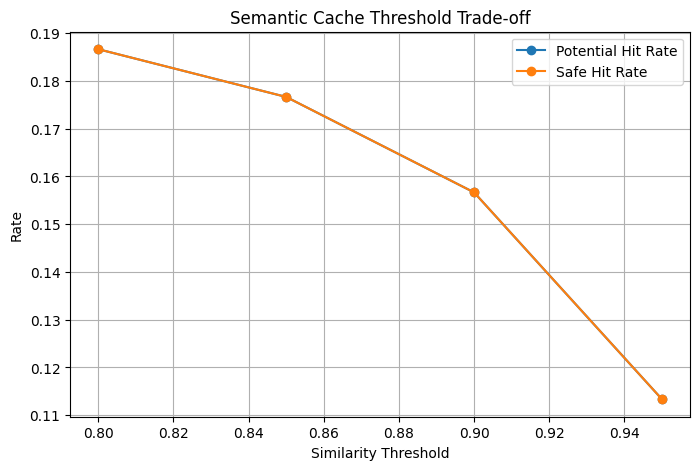

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df["threshold"],
    threshold_df["potential_hit_rate"],
    marker="o",
    label="Potential Hit Rate"
)
plt.plot(
    threshold_df["threshold"],
    threshold_df["safe_hit_rate"],
    marker="o",
    label="Safe Hit Rate"
)
plt.xlabel("Similarity Threshold")
plt.ylabel("Rate")
plt.title(
    "Semantic Cache Threshold Trade-off"
)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
threshold_df.to_csv(
    "semantic_cache_threshold_results.csv",
    index=False
)
print(
    "Threshold experiment saved."
)

Threshold experiment saved.


In [ ]:
semantic_cache = []
print("Cache reset.")

Cache reset.


In [ ]:
base_queries = queries_df["query"].iloc[:10].tolist()
experiment_queries = (
    base_queries +
    base_queries
)
print("Total requests:", len(experiment_queries))
print("Unique queries:", len(set(experiment_queries)))

Total requests: 20
Unique queries: 10


In [ ]:
import time
no_cache_results = []
for i, query in enumerate(
    experiment_queries,start=1
):
    start = time.perf_counter()
    result = baseline_rag(
        query,top_k=5,model="openai/gpt-oss-120b"
    )
    end = time.perf_counter()
    usage = result["usage"]
    input_tokens = getattr(
        usage,"prompt_tokens",0
    )
    output_tokens = getattr(
        usage,"completion_tokens",0
    )
    no_cache_results.append({
        "query": query,"latency_sec": end - start,"input_tokens": input_tokens,
        "output_tokens": output_tokens, "total_tokens": (
            input_tokens + output_tokens
        )
    })
    print(
        f"Request {i}/20 completed | "
        f"Latency: {end-start:.2f}s"
    )

Request 1/20 completed | Latency: 0.98s
Request 2/20 completed | Latency: 1.11s
Request 3/20 completed | Latency: 1.13s
Request 4/20 completed | Latency: 1.10s
Request 5/20 completed | Latency: 11.87s
Request 6/20 completed | Latency: 14.03s
Request 7/20 completed | Latency: 16.20s
Request 8/20 completed | Latency: 19.36s
Request 9/20 completed | Latency: 16.17s
Request 10/20 completed | Latency: 11.07s
Request 11/20 completed | Latency: 9.30s
Request 12/20 completed | Latency: 18.55s
Request 13/20 completed | Latency: 26.63s
Request 14/20 completed | Latency: 16.16s
Request 15/20 completed | Latency: 14.23s
Request 16/20 completed | Latency: 15.39s
Request 17/20 completed | Latency: 3.95s
Request 18/20 completed | Latency: 6.27s
Request 19/20 completed | Latency: 16.02s
Request 20/20 completed | Latency: 11.06s


In [ ]:
semantic_cache = []

In [ ]:
cache_results = []
for i, query in enumerate(
    experiment_queries,start=1
):
    result = semantic_cached_rag(
        query,top_k=5,similarity_threshold=0.90,model="openai/gpt-oss-120b"
    )
    cache_results.append(result)
    print(
        f"Request {i}/20 | "
        f"Hit: {result['cache_hit']} | "
        f"Latency: {result['latency_sec']:.4f}s"
    )

Request 1/20 | Hit: False | Latency: 7.9966s
Request 2/20 | Hit: False | Latency: 19.5748s
Request 3/20 | Hit: False | Latency: 15.2210s
Request 4/20 | Hit: False | Latency: 16.4096s
Request 5/20 | Hit: False | Latency: 0.9209s
Request 6/20 | Hit: False | Latency: 15.2782s
Request 7/20 | Hit: True | Latency: 0.0369s
Request 8/20 | Hit: False | Latency: 19.3463s
Request 9/20 | Hit: False | Latency: 16.1335s
Request 10/20 | Hit: False | Latency: 12.2012s
Request 11/20 | Hit: True | Latency: 0.0229s
Request 12/20 | Hit: True | Latency: 0.0224s
Request 13/20 | Hit: True | Latency: 0.0247s
Request 14/20 | Hit: True | Latency: 0.0247s
Request 15/20 | Hit: True | Latency: 0.0282s
Request 16/20 | Hit: True | Latency: 0.0396s
Request 17/20 | Hit: True | Latency: 0.0322s
Request 18/20 | Hit: True | Latency: 0.0354s
Request 19/20 | Hit: True | Latency: 0.0217s
Request 20/20 | Hit: True | Latency: 0.0241s


In [ ]:
cache_stats = calculate_cache_statistics(cache_results)
print("Total requests:",cache_stats["total_requests"])
print("Cache hits:",cache_stats["cache_hits"])
print("Cache misses:",cache_stats["cache_misses"])
print("Cache hit rate:",round(cache_stats["cache_hit_rate"] * 100,2),"%")

Total requests: 20
Cache hits: 11
Cache misses: 9
Cache hit rate: 55.0 %


In [ ]:
no_cache_df = pd.DataFrame(no_cache_results)
cache_df = pd.DataFrame([
    {
        "query": r["query"],
        "cache_hit": r["cache_hit"],
        "latency_sec": r["latency_sec"],
        "input_tokens": r["input_tokens"],
        "output_tokens": r["output_tokens"],
        "total_tokens": r["total_tokens"]
    }
    for r in cache_results
])

In [ ]:
print("Average latency WITHOUT cache:",
    round(no_cache_df["latency_sec"].mean(),4),"seconds"
)
print("Average latency WITH cache:",
    round(cache_df["latency_sec"].mean(),4),"seconds")

Average latency WITHOUT cache: 11.5288 seconds
Average latency WITH cache: 6.1698 seconds


In [ ]:
baseline_avg_latency = (no_cache_df["latency_sec"].mean())
cached_avg_latency = (cache_df["latency_sec"].mean())
latency_reduction = (
    1 - cached_avg_latency /baseline_avg_latency) * 100
print("Latency reduction:",round(latency_reduction, 2),"%")

Latency reduction: 46.48 %


In [ ]:
llm_calls_without_cache = len(no_cache_results)
llm_calls_with_cache = sum(not r["cache_hit"]for r in cache_results)
llm_calls_avoided = (llm_calls_without_cache -llm_calls_with_cache)
print("LLM calls without cache:",llm_calls_without_cache)
print("LLM calls with cache:",llm_calls_with_cache)
print("LLM calls avoided:",llm_calls_avoided)

LLM calls without cache: 20
LLM calls with cache: 9
LLM calls avoided: 11


In [ ]:
tokens_without_cache = (no_cache_df["total_tokens"].sum())
tokens_with_cache = (cache_df["total_tokens"].sum())
tokens_saved = (tokens_without_cache -tokens_with_cache)
token_reduction = (
    1 - tokens_with_cache/tokens_without_cache) * 100
print("Tokens without cache:",tokens_without_cache)
print("Tokens with cache:",tokens_with_cache)
print("Tokens saved:",tokens_saved)
print("Token reduction:",round(token_reduction, 2),"%")

Tokens without cache: 40271
Tokens with cache: 18119
Tokens saved: 22152
Token reduction: 55.01 %


In [ ]:
def calculate_llm_cost(input_tokens,output_tokens):
    input_cost = (input_tokens / 1_000_000) * 0.15
    output_cost = (output_tokens / 1_000_000) * 0.60
    return input_cost + output_cost

In [ ]:
no_cache_input = (no_cache_df["input_tokens"].sum())
no_cache_output = (no_cache_df["output_tokens"].sum())
no_cache_cost = calculate_llm_cost(
    no_cache_input,no_cache_output)
print(
    "Cost WITHOUT cache: "
    f"${no_cache_cost:.6f}"
)

Cost WITHOUT cache: $0.007772


In [ ]:
cache_input = (cache_df["input_tokens"].sum())
cache_output = (cache_df["output_tokens"].sum())
cache_cost = calculate_llm_cost(
    cache_input,cache_output)
print(
    "Cost WITH cache: "
    f"${cache_cost:.6f}"
)

Cost WITH cache: $0.003535


In [ ]:
cost_reduction = (1 -cache_cost /no_cache_cost) * 100
cost_saved = (no_cache_cost - cache_cost)
print("Cost saved:",
    f"${cost_saved:.6f}")
print("Cost reduction:",
    round(cost_reduction, 2),"%")

Cost saved: $0.004237
Cost reduction: 54.51 %


In [ ]:
cache_experiment_summary = pd.DataFrame([{
    "total_requests": len(experiment_queries),
    "cache_hits": cache_stats["cache_hits"],
    "cache_hit_rate": (cache_stats["cache_hit_rate"]),
    "llm_calls_without_cache":
        llm_calls_without_cache,
    "llm_calls_with_cache":
        llm_calls_with_cache,
    "llm_calls_avoided":
        llm_calls_avoided,
    "avg_latency_without_cache":
        baseline_avg_latency,
    "avg_latency_with_cache":
        cached_avg_latency,
    "latency_reduction_pct":
        latency_reduction,
    "tokens_without_cache":
        tokens_without_cache,
    "tokens_with_cache":
        tokens_with_cache,
    "tokens_saved":
        tokens_saved,
    "token_reduction_pct":
        token_reduction,
    "cost_without_cache":
        no_cache_cost,
    "cost_with_cache":
        cache_cost,
    "cost_saved":
        cost_saved,
    "cost_reduction_pct":
        cost_reduction
}])
cache_experiment_summary.T

,0
total_requests,20.000000
cache_hits,11.000000
cache_hit_rate,0.550000
llm_calls_without_cache,20.000000
llm_calls_with_cache,9.000000
llm_calls_avoided,11.000000
avg_latency_without_cache,11.528835
avg_latency_with_cache,6.169751
latency_reduction_pct,46.484177
tokens_without_cache,40271.000000


In [ ]:
cache_experiment_summary.to_csv(
    "semantic_cache_experiment_summary.csv",index=False
)
cache_df.to_csv(
    "semantic_cache_request_results.csv",index=False
)
print("Semantic cache experiment results saved.")

Semantic cache experiment results saved.


In [ ]:
semantic_cache = []
print("Semantic cache reset.")

Semantic cache reset.


In [ ]:
similar_pairs = (
    pair_df.sort_values("similarity",ascending=False).head(15)
)
similar_pairs[
    [
        "query_id","nearest_query_id","similarity",
        "relevance_jaccard","relevance_compatible"
    ]
]

,query_id,nearest_query_id,similarity,relevance_jaccard,relevance_compatible
218,1021,1020,0.997873,1.0,True
217,1020,1021,0.997873,1.0,True
111,532,533,0.997372,1.0,True
112,533,532,0.997372,1.0,True
12,56,57,0.995211,1.0,True
13,57,56,0.995211,1.0,True
33,143,142,0.994825,1.0,True
32,142,143,0.994825,1.0,True
49,219,218,0.993337,1.0,True
48,218,219,0.993337,1.0,True


In [ ]:
for _, row in similar_pairs.head(10).iterrows():
    q1 = queries[str(row["query_id"])]
    q2 = queries[str(row["nearest_query_id"])]
    print("-" * 80)
    print("Query A:")
    print(q1)
    print("\nQuery B:")
    print(q2)
    print(
        "\nEmbedding similarity:",round(row["similarity"], 4)
    )
    print(
        "Relevance Jaccard:",round(row["relevance_jaccard"], 4)
    )
    print(
        "Relevance compatible:",row["relevance_compatible"]
    )
    print()

--------------------------------------------------------------------------------
Query A:
Rapid up-regulation and higher basal expression of interferon-induced genes reduce survival of granule cell neurons that are infected by West Nile virus.

Query B:
Rapid up-regulation and higher basal expression of interferon-induced genes increase survival of granule cell neurons that are infected by West Nile virus.

Embedding similarity: 0.9979
Relevance Jaccard: 1.0
Relevance compatible: True

--------------------------------------------------------------------------------
Query A:
Rapid up-regulation and higher basal expression of interferon-induced genes increase survival of granule cell neurons that are infected by West Nile virus.

Query B:
Rapid up-regulation and higher basal expression of interferon-induced genes reduce survival of granule cell neurons that are infected by West Nile virus.

Embedding similarity: 0.9979
Relevance Jaccard: 1.0
Relevance compatible: True

------------------

In [ ]:
candidate_pairs = pair_df[
    (pair_df["similarity"] >= 0.90) &(pair_df["relevance_compatible"])
].sort_values("similarity",ascending=False)
print("Candidate pairs:",len(candidate_pairs))

Candidate pairs: 47


In [ ]:
selected_pair = candidate_pairs.iloc[0]
query_a_id = str(selected_pair["query_id"])
query_b_id = str(selected_pair["nearest_query_id"])
query_a = queries[query_a_id]
query_b = queries[query_b_id]
print("QUERY A:")
print(query_a)
print("\nQUERY B:")
print(query_b)
print("\nSimilarity:",round(selected_pair["similarity"],4))
print(
    "Relevance Jaccard:",
    round(
        selected_pair["relevance_jaccard"],4
    )
)

QUERY A:
Rapid up-regulation and higher basal expression of interferon-induced genes reduce survival of granule cell neurons that are infected by West Nile virus.

QUERY B:
Rapid up-regulation and higher basal expression of interferon-induced genes increase survival of granule cell neurons that are infected by West Nile virus.

Similarity: 0.9979
Relevance Jaccard: 1.0


In [ ]:
result_a = semantic_cached_rag(
    query_a,top_k=5,similarity_threshold=0.90,
    model="openai/gpt-oss-120b"
)
print("Query A:")
print(query_a)
print("\nCache hit:")
print(result_a["cache_hit"])
print(
    "\nLatency:",
    round(
        result_a["latency_sec"],4),"seconds"
)

Query A:
Rapid up-regulation and higher basal expression of interferon-induced genes reduce survival of granule cell neurons that are infected by West Nile virus.

Cache hit:
False

Latency: 1.3449 seconds


In [ ]:
result_b = semantic_cached_rag(
    query_b,top_k=5,
    similarity_threshold=0.90,model="openai/gpt-oss-120b"
)
print("Query B:")
print(query_b)
print("\nCache hit:")
print(result_b["cache_hit"])
print(
    "\nCache similarity:",
    round(
        result_b["cache_similarity"],4
    ) if result_b["cache_similarity"] is not None
    else None
)
print(
    "\nLatency:",
    round(
        result_b["latency_sec"],4
    ),"seconds"
)
print(
    "\nTokens used:",
    result_b["total_tokens"]
)

Query B:
Rapid up-regulation and higher basal expression of interferon-induced genes increase survival of granule cell neurons that are infected by West Nile virus.

Cache hit:
True

Cache similarity: 0.9979

Latency: 0.0515 seconds

Tokens used: 0


In [ ]:
independent_b = baseline_rag(
    query_b,top_k=5,
    model="openai/gpt-oss-120b"
)
print("INDEPENDENT ANSWER FOR QUERY B:")
print(independent_b["answer"])

INDEPENDENT ANSWER FOR QUERY B:
Yes. The documents report that cerebellar granule cell neurons express higher basal levels of interferon‑stimulated genes (e.g., Ifi27, Irg1, Rsad2) and can rapidly up‑regulate additional ISGs, which confers a stronger antiviral state and improves their survival when infected with West Nile virus.


In [ ]:
print("-" * 80)
print("QUERY B:")
print(query_b)
print("\nCACHED ANSWER:")
print(result_b["answer"])
print("\nINDEPENDENT BASELINE ANSWER:")
print(independent_b["answer"])

--------------------------------------------------------------------------------
QUERY B:
Rapid up-regulation and higher basal expression of interferon-induced genes increase survival of granule cell neurons that are infected by West Nile virus.

CACHED ANSWER:
The provided documents do not contain information supporting the claim that rapid up‑regulation and higher basal expression of interferon‑induced genes reduce the survival of granule cell neurons infected with West Nile virus. In fact, the cited studies describe granule cell neurons as having a distinctive innate immune program that confers enhanced antiviral resistance. Therefore, the statement is not supported by the given context.

INDEPENDENT BASELINE ANSWER:
Yes. The documents report that cerebellar granule cell neurons express higher basal levels of interferon‑stimulated genes (e.g., Ifi27, Irg1, Rsad2) and can rapidly up‑regulate additional ISGs, which confers a stronger antiviral state and improves their survival when in

In [ ]:
answer_embeddings = embedding_model.encode(
    [
        result_b["answer"],independent_b["answer"]
    ],normalize_embeddings=True
)

answer_similarity = cosine_similarity(
    answer_embeddings[0],answer_embeddings[1]
)

print(
    "Answer semantic similarity:",round(answer_similarity, 4)
)

Answer semantic similarity: 0.7812


In [ ]:
cached_doc_ids = [
    doc["doc_id"]
    for doc in result_b["retrieved_documents"]
]
independent_doc_ids = [
    doc["doc_id"]
    for doc in independent_b["retrieved_documents"]
]
print("Cached document IDs:")
print(cached_doc_ids)
print("\nIndependent document IDs:")
print(independent_doc_ids)

Cached document IDs:
['10559501', '9433958', '12885341', '2947124', '8979167']

Independent document IDs:
['10559501', '9433958', '12885341', '2947124', '8979167']


In [ ]:
doc_overlap = (
    len(
        set(cached_doc_ids) & set(independent_doc_ids)
    )/len(
        set(cached_doc_ids) | set(independent_doc_ids)
    )
)
print(
    "\nDocument Jaccard overlap:",round(doc_overlap, 4)
)


Document Jaccard overlap: 1.0


In [ ]:
semantic_pair_result = pd.DataFrame([{
    "query_a": query_a,"query_b": query_b,
    "query_similarity":float(selected_pair["similarity"]),
    "relevance_jaccard":float(selected_pair["relevance_jaccard"]),
    "cache_hit":result_b["cache_hit"],
    "cache_similarity":result_b["cache_similarity"],
    "answer_similarity":answer_similarity,
    "document_jaccard":doc_overlap,
    "cached_latency_sec":result_b["latency_sec"]
}])
semantic_pair_result

,query_a,query_b,query_similarity,relevance_jaccard,cache_hit,cache_similarity,answer_similarity,document_jaccard,cached_latency_sec
0,Rapid up-regulation and higher basal expressio...,Rapid up-regulation and higher basal expressio...,0.997873,1.0,True,0.997873,0.781246,1.0,0.051461


In [ ]:
semantic_pair_result.to_csv(
    "semantic_paraphrase_experiment.csv",index=False
)
print("Semantic paraphrase experiment saved.")

Semantic paraphrase experiment saved.


In [ ]:
test_pairs = candidate_pairs.head(5)
semantic_experiment_results = []
for _, row in test_pairs.iterrows():

    q1_id = str(row["query_id"])
    q2_id = str(row["nearest_query_id"])
    q1 = queries[q1_id]
    q2 = queries[q2_id]
    semantic_cache = []
    first_result = semantic_cached_rag(
        q1,top_k=5,similarity_threshold=0.90,
        model="openai/gpt-oss-120b"
    )
    cached_result = semantic_cached_rag(
        q2,top_k=5,similarity_threshold=0.90,
        model="openai/gpt-oss-120b"
    )
    independent_result = baseline_rag(
        q2,top_k=5,model="openai/gpt-oss-120b"
    )
    embeddings = embedding_model.encode(
        [
            cached_result["answer"],independent_result["answer"]
        ],normalize_embeddings=True
    )

    answer_sim = cosine_similarity(
        embeddings[0],embeddings[1]
    )
    cached_docs = {
        d["doc_id"]
        for d in cached_result["retrieved_documents"]
    }
    independent_docs = {
        d["doc_id"]
        for d in independent_result["retrieved_documents"]
    }
    union = cached_docs | independent_docs
    if union:
        doc_jaccard = (len(cached_docs & independent_docs) / len(union)
        )
    else:
        doc_jaccard = 0
    semantic_experiment_results.append({
        "query_a_id": q1_id,
        "query_b_id": q2_id,
        "query_similarity":float(row["similarity"]),
        "relevance_jaccard":float(row["relevance_jaccard"]),
        "cache_hit":cached_result["cache_hit"],
        "cache_similarity":cached_result["cache_similarity"],
        "answer_similarity":answer_sim,
        "document_jaccard":doc_jaccard
    })
semantic_experiment_df = pd.DataFrame(
    semantic_experiment_results
)
semantic_experiment_df

,query_a_id,query_b_id,query_similarity,relevance_jaccard,cache_hit,cache_similarity,answer_similarity,document_jaccard
0,1021,1020,0.997873,1.0,True,0.997873,0.821144,1.0
1,1020,1021,0.997873,1.0,True,0.997873,0.828235,1.0
2,532,533,0.997372,1.0,True,0.997372,0.919741,1.0
3,533,532,0.997372,1.0,True,0.997372,0.856168,1.0
4,56,57,0.995211,1.0,True,0.995211,0.880563,1.0


In [ ]:
semantic_experiment_df.to_csv(
    "semantic_cache_semantic_similarity_results.csv",index=False
)
print("Semantic similarity results saved.")

Semantic similarity results saved.


In [ ]:
final_cache_comparison = pd.DataFrame([
    {
        "Metric": "Total Requests",
        "Baseline RAG": len(experiment_queries),
        "Semantic Cache": len(experiment_queries)
    },
    {
        "Metric": "LLM Calls","Baseline RAG": llm_calls_without_cache,
        "Semantic Cache": llm_calls_with_cache
    },
    {
        "Metric": "LLM Calls Avoided","Baseline RAG": 0,
        "Semantic Cache": llm_calls_avoided
    },
    {
        "Metric": "Cache Hit Rate","Baseline RAG": 0.0,
        "Semantic Cache": cache_stats["cache_hit_rate"]
    },
    {
        "Metric": "Average Latency (sec)","Baseline RAG": baseline_avg_latency,
        "Semantic Cache": cached_avg_latency
    },
    {
        "Metric": "Latency Reduction (%)","Baseline RAG": 0,
        "Semantic Cache": latency_reduction
    },
    {
        "Metric": "Total Tokens","Baseline RAG": tokens_without_cache,
        "Semantic Cache": tokens_with_cache
    },
    {
        "Metric": "Tokens Saved","Baseline RAG": 0,
        "Semantic Cache": tokens_saved
    },
    {
        "Metric": "Token Reduction (%)","Baseline RAG": 0,
        "Semantic Cache": token_reduction
    },
    {
        "Metric": "Estimated Cost ($)","Baseline RAG": no_cache_cost,
        "Semantic Cache": cache_cost
    },
    {
        "Metric": "Cost Saved ($)","Baseline RAG": 0,
        "Semantic Cache": cost_saved
    },
    {
        "Metric": "Cost Reduction (%)","Baseline RAG": 0,
        "Semantic Cache": cost_reduction
    }
])
final_cache_comparison

,Metric,Baseline RAG,Semantic Cache
0,Total Requests,20.000000,20.000000
1,LLM Calls,20.000000,9.000000
2,LLM Calls Avoided,0.000000,11.000000
3,Cache Hit Rate,0.000000,0.550000
4,Average Latency (sec),11.528835,6.169751
5,Latency Reduction (%),0.000000,46.484177
6,Total Tokens,40271.000000,18119.000000
7,Tokens Saved,0.000000,22152.000000
8,Token Reduction (%),0.000000,55.007325
9,Estimated Cost ($),0.007772,0.003535


In [ ]:
display(
    final_cache_comparison.style.format({
        "Baseline RAG": "{:.4f}","Semantic Cache": "{:.4f}"
    })
)

,Metric,Baseline RAG,Semantic Cache
0,Total Requests,20.0000,20.0000
1,LLM Calls,20.0000,9.0000
2,LLM Calls Avoided,0.0000,11.0000
3,Cache Hit Rate,0.0000,0.5500
4,Average Latency (sec),11.5288,6.1698
5,Latency Reduction (%),0.0000,46.4842
6,Total Tokens,40271.0000,18119.0000
7,Tokens Saved,0.0000,22152.0000
8,Token Reduction (%),0.0000,55.0073
9,Estimated Cost ($),0.0078,0.0035


In [ ]:
final_cache_comparison.to_csv(
    "semantic_cache_final_comparison.csv",index=False
)
print("Final semantic cache comparison saved.")

Final semantic cache comparison saved.


In [ ]:
threshold_df.to_csv(
    "semantic_cache_threshold_results.csv",index=False
)
semantic_experiment_df.to_csv(
    "semantic_cache_semantic_similarity_results.csv",index=False
)
print("All Notebook 2 experiment results saved.")

All Notebook 2 experiment results saved.


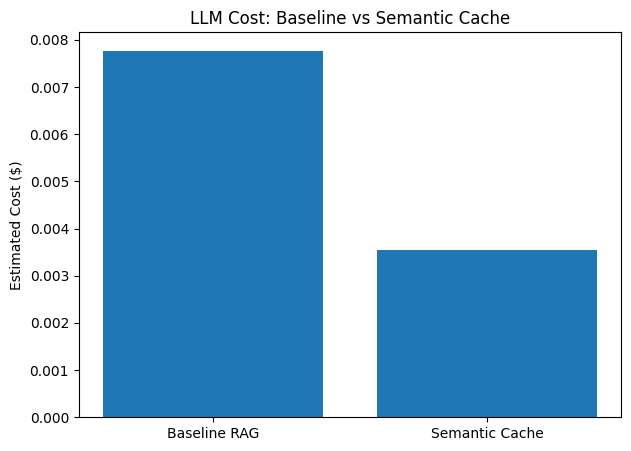

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(
    ["Baseline RAG", "Semantic Cache"],[no_cache_cost, cache_cost]
)
plt.ylabel("Estimated Cost ($)")
plt.title("LLM Cost: Baseline vs Semantic Cache")
plt.show()

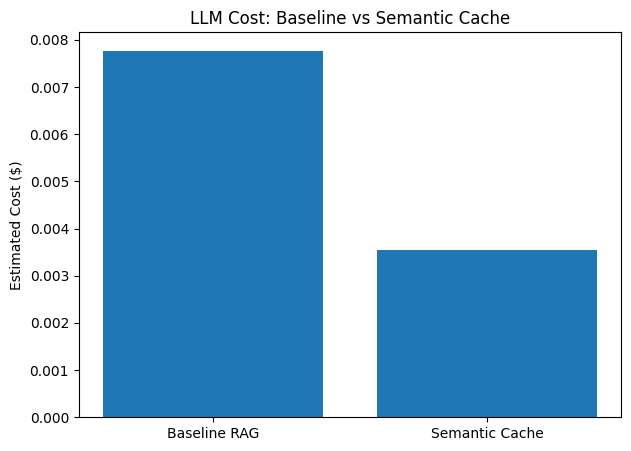

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(
    ["Baseline RAG", "Semantic Cache"],[no_cache_cost, cache_cost]
)
plt.ylabel("Estimated Cost ($)")
plt.title("LLM Cost: Baseline vs Semantic Cache")
plt.show()